In [1]:
import warnings
warnings.filterwarnings("ignore")

<xarray.DataArray 'bz' (y: 600, x: 960)> Size: 5MB
array([[ 352.40587477,   94.8913792 ,   41.61924299, ...,  470.18833933,
         129.20055397,   18.50120941],
       [ 525.04809649,  624.84659897,   53.45418   , ...,  450.42515609,
         240.12455308,  -73.61367693],
       [ 105.0939369 ,  638.76559489,  307.60736872, ...,  236.91326522,
         386.8498122 ,  -86.44215589],
       ...,
       [ -83.74367957,   32.98078244, -411.75073652, ...,  745.99373583,
        1036.20033954, -140.64317643],
       [ 171.17113661, -214.47801235,  159.23437984, ...,  124.58138395,
         258.54331931,  -90.3376945 ],
       [  80.60950354,  273.08367487,  118.23499313, ...,   -4.19572521,
         -53.55728012,    2.10335918]], shape=(600, 960))
Coordinates:
  * y        (y) float64 5kB 0.0 2.35 4.7 7.05 ... 1.403e+03 1.405e+03 1.408e+03
  * x        (x) float64 8kB 0.0 2.35 4.7 7.05 ... 2.249e+03 2.251e+03 2.254e+03
    z        (y, x) float64 5MB 5.0 5.0 5.0 5.0 5.0 5.0 ... 5.0 5.0 5.0

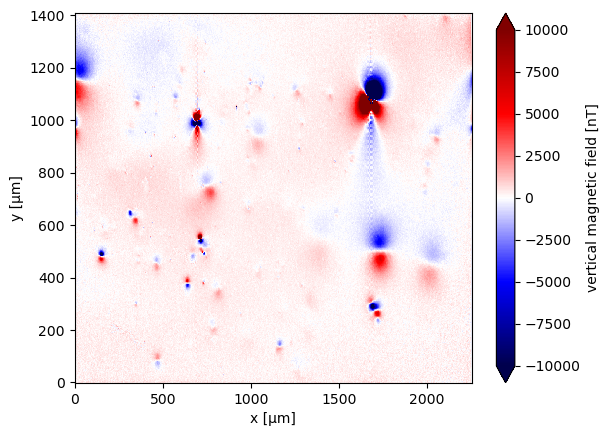

In [2]:
import numpy as np
import magali as mg
import harmonica as hm
import skimage.exposure
import xarray as xr
import matplotlib.pyplot as plt
import ensaio

fname = ensaio.fetch_morroco_speleothem_qdm(version=1, file_format="matlab")
data = mg.read_qdm_harvard(fname)

data.plot.pcolormesh(cmap="seismic", vmin=-10000, vmax=10000)

print(data)

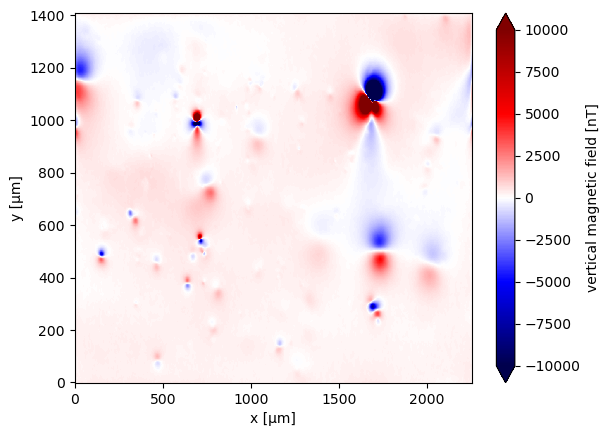

In [3]:
import numpy as np
import magali as mg
import harmonica as hm
import skimage.exposure
import xarray as xr
import matplotlib.pyplot as plt
import ensaio

fname = ensaio.fetch_morroco_speleothem_qdm(version=1, file_format="matlab")
data = mg.read_qdm_harvard(fname)

height_difference = 5.0

data_up = (
    hm.upward_continuation(data, height_difference)
    .assign_attrs(data.attrs)
    .assign_coords(x=data.x, y=data.y)
    .assign_coords(z=data.z + height_difference)
    .rename("bz")
)

data_up.plot.pcolormesh(cmap="seismic", vmin=-10000, vmax=10000)

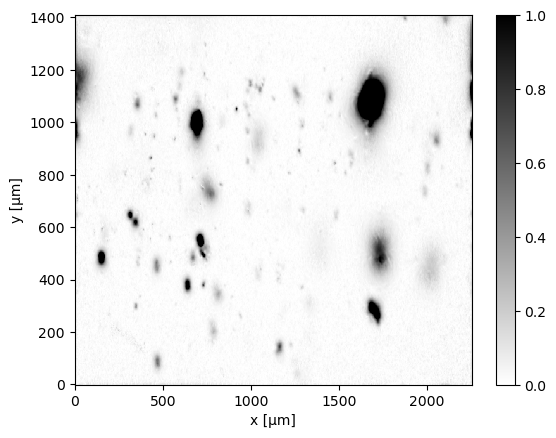

In [4]:
import numpy as np
import magali as mg
import harmonica as hm
import skimage.exposure
import xarray as xr
import matplotlib.pyplot as plt
import ensaio

fname = ensaio.fetch_morroco_speleothem_qdm(version=1, file_format="matlab")
data = mg.read_qdm_harvard(fname)

height_difference = 5.0

data_up = (
    hm.upward_continuation(data, height_difference)
    .assign_attrs(data.attrs)
    .assign_coords(x=data.x, y=data.y)
    .assign_coords(z=data.z + height_difference)
    .rename("bz")
)

dx, dy, dz, tga = mg.gradient(data_up)
data_up["dx"], data_up["dy"], data_up["dz"], data_up["tga"] = dx, dy, dz, tga

stretched = skimage.exposure.rescale_intensity(
    tga, in_range=tuple(np.percentile(tga, (1, 99)))
)
data_tga_stretched = xr.DataArray(stretched, coords=data_up.coords)

data_tga_stretched.plot.pcolormesh(cmap="gray_r")

<Axes: xlabel='x [µm]', ylabel='y [µm]'>

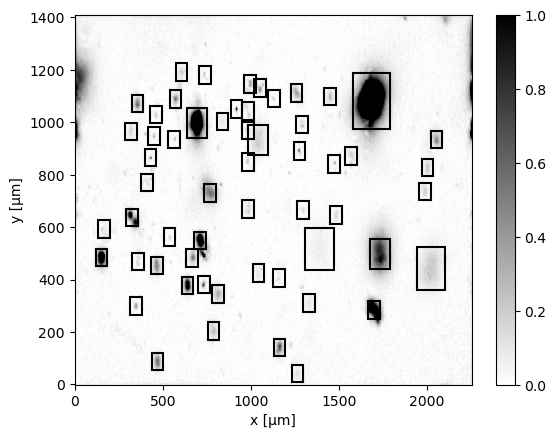

In [5]:
import numpy as np
import magali as mg
import harmonica as hm
import skimage.exposure
import xarray as xr
import matplotlib.pyplot as plt
import ensaio

fname = ensaio.fetch_morroco_speleothem_qdm(version=1, file_format="matlab")
data = mg.read_qdm_harvard(fname)

height_difference = 5.0

data_up = (
    hm.upward_continuation(data, height_difference)
    .assign_attrs(data.attrs)
    .assign_coords(x=data.x, y=data.y)
    .assign_coords(z=data.z + height_difference)
    .rename("bz")
)

dx, dy, dz, tga = mg.gradient(data_up)
data_up["dx"], data_up["dy"], data_up["dz"], data_up["tga"] = dx, dy, dz, tga

stretched = skimage.exposure.rescale_intensity(
    tga, in_range=tuple(np.percentile(tga, (1, 99)))
)
data_tga_stretched = xr.DataArray(stretched, coords=data_up.coords)

bounding_boxes = mg.detect_anomalies(
    data_tga_stretched,
    size_range=[20, 150],
    detection_threshold=0.02,
    border_exclusion=2,
)

fig, ax = plt.subplots()
data_tga_stretched.plot.pcolormesh(cmap="gray_r")
mg.plot_bounding_boxes(bounding_boxes, ax=ax, color="black", linewidth=1.5)


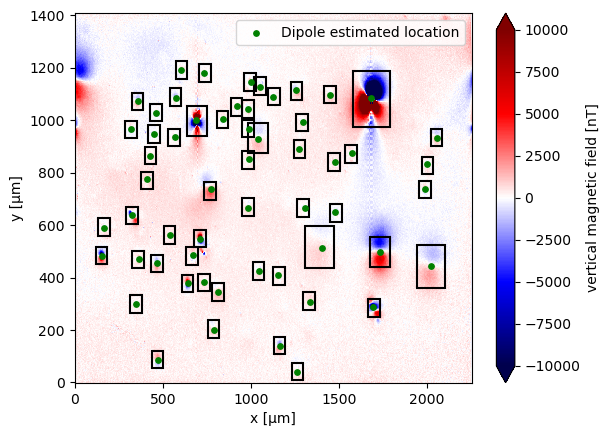

In [6]:
import numpy as np
import magali as mg
import harmonica as hm
import skimage.exposure
import xarray as xr
import matplotlib.pyplot as plt
import ensaio

fname = ensaio.fetch_morroco_speleothem_qdm(version=1, file_format="matlab")
data = mg.read_qdm_harvard(fname)

height_difference = 5.0

data_up = (
    hm.upward_continuation(data, height_difference)
    .assign_attrs(data.attrs)
    .assign_coords(x=data.x, y=data.y)
    .assign_coords(z=data.z + height_difference)
    .rename("bz")
)

dx, dy, dz, tga = mg.gradient(data_up)
data_up["dx"], data_up["dy"], data_up["dz"], data_up["tga"] = dx, dy, dz, tga

stretched = skimage.exposure.rescale_intensity(
    tga, in_range=tuple(np.percentile(tga, (1, 99)))
)
data_tga_stretched = xr.DataArray(stretched, coords=data_up.coords)

bounding_boxes = mg.detect_anomalies(
    data_tga_stretched,
    size_range=[20, 150],
    detection_threshold=0.02,
    border_exclusion=2,
)

data_updated, locations_, dipole_moments_, r2_values = mg.iterative_nonlinear_inversion(
    data_up,
    bounding_boxes,
    height_difference=height_difference,
    copy_data=True,
)

fig, ax = plt.subplots()
data.plot.pcolormesh(ax=ax, cmap="seismic", vmin=-10000, vmax=10000)
mg.plot_bounding_boxes(bounding_boxes, ax=ax, color="black", linewidth=1.5)
locations_arr = np.array(locations_)
ax.scatter(
    locations_arr[:, 0],  # x
    locations_arr[:, 1],  # y
    c="green",
    marker=".",
    s=60,
    label="Dipole estimated location"
)
plt.legend()
plt.show()


In [7]:
moments = np.array(dipole_moments_)


mx = moments[:, 0]
my = moments[:, 1]
mz = moments[:, 2]

In [ ]:
np.shape(dipole_moments_)#[0]
r2_values

[np.float64(0.8887574906799602),
 np.float64(0.22160663068076458),
 np.float64(0.9976624416134007),
 np.float64(-2.161830267646352),
 np.float64(-0.07522633645317356),
 np.float64(-0.007656956204557641),
 np.float64(0.9990991590908861),
 np.float64(-9.567533139974321),
 np.float64(-2.0769342961044246),
 np.float64(-17.58985086599744),
 np.float64(-0.437395870694671),
 np.float64(-0.6280509122063131),
 np.float64(-5.080603651875455),
 np.float64(-23.678174849471116),
 np.float64(-1.5571962926648872),
 np.float64(-2.3325668162913966),
 np.float64(-743.3146145610935),
 np.float64(-77.95515094292598),
 np.float64(-103.08762142310552),
 np.float64(-3.2444875787743586),
 np.float64(-0.8416466356508086),
 np.float64(-19.46454423649432),
 np.float64(-0.11237669783851811),
 np.float64(-8.502455290916622),
 np.float64(-4.04998770040548),
 np.float64(-8.858595759194936),
 np.float64(-4.656625151808816),
 np.float64(-2.132198039562269),
 np.float64(-4.351610161554831),
 np.float64(-4.9718842707523

In [10]:
def vector_to_angles(vector):
    """
    Generate inclination, declination, and amplitude from a 3-component vector

    Inclination is positive downwards and declination is the angle with the y
    component. The vector has x, y, and z (upward) Cartesian components.

    Parameters
    ----------
    vector : 1D or 2D array
        The x, y, z vector components. Can be a 1D array for a single vector
        or 2D for multiple. If 2D, then each vector should be a row of the
        array.

    Returns
    -------
    inclination : float or array
        The inclination values in degrees.
    declination : float or array
        The declination values in degrees.
    amplitude : float or array
        The vector amplitude values.
    """
    vector = np.asarray(vector)
    x, y, z = vector.T
    amplitude = np.sqrt(x**2 + y**2 + z**2)
    inclination = -np.degrees(np.arctan2(z, np.hypot(x, y)))
    declination = np.degrees(np.arctan2(x, y))
    return inclination, declination, amplitude



def plot_stereonet(dipole_moments, ax=None, cmap="plasma", cmap_norm=plt.Normalize, vmin=None, vmax=None, label="", add_ticks=True, **kwargs):
    """
    Plot the dipole moments in a stereonet.
    
    The moment magnitude is set as the color. 
    Positive inclination symbols are solid, negative are just the outline.
    """
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(1, 1, 1, projection='stereonet')

    ax.set_facecolor("#eeeeee") # color "#eeeeee"
    ax.grid(linestyle="-", color="#cccccc", linewidth=1)
    ax.set_longitude_grid_ends(90)
    if add_ticks:
        # Add ticks manually because mplstereonet doesn't work with subplots
        ax.set_azimuth_ticks([])
        ax.text(0.2, 1.65, '0°')
        ax.text(0.2, -1.8, '180°')
        ax.text(-2, -0.025, '270°')
        ax.text(1.65, -0.025, '90°')
    
    if label and not label.endswith(" "):
        label = label + " "
    
    inclination, declination, amplitude = vector_to_angles(dipole_moments)
    
    # Generate colors based on the amplitude values
    norm = cmap_norm(vmin=vmin, vmax=vmax)
    colors = plt.colormaps[cmap](norm(amplitude))
    
    positive_inc = inclination > 0
    ax.scatter(
        *mplstereonet.line(inclination[positive_inc], declination[positive_inc]),
        c=colors[positive_inc],
        label=f"{label}$I > 0$",
        edgecolors="#333333",
        **kwargs,
    )
    ax.scatter(
        *mplstereonet.line(-inclination[~positive_inc], declination[~positive_inc]),
        c="#ffffff00",
        label=f"{label}$I \le 0$",
        edgecolors=colors[~positive_inc],
        **kwargs,
    )

    mappable = plt.cm.ScalarMappable(norm, cmap=cmap)
    return mappable


def equal_area_projection(vectors):
    # norm = np.linalg.norm(vectors, axis=1)
    # vectors_unitary = vectors / norm[:, np.newaxis]
    vectors = np.asarray(vectors)
    vectors_unitary = np.empty_like(vectors)
    for i in range(vectors.shape[0]):
        vector = vectors[i]  
        norm = np.sqrt(np.sum(vector ** 2))
        vectors_unitary[i] = vector / norm
    inclinations, declinations, amplitudes = vector_to_angles(vectors)

    # XY_projected = np.zeros((len(vectors), 3))
    XY_projected = np.empty_like(vectors)
    for i, projected_vector in enumerate(vectors_unitary):
        r = np.sqrt(1 - np.abs(vectors_unitary[i, 2])) / np.sqrt(vectors_unitary[i, 0]**2 + vectors_unitary[i, 1]**2)
        XY_projected[i, 0] = r * vectors_unitary[i, 1]
        XY_projected[i, 1] = r * vectors_unitary[i, 0]
        XY_projected[i, 2] = amplitudes[i] if inclinations[i] >= 0 else -amplitudes[i]

    return XY_projected


class StereographicProjection:
    def __init__(self, vectors):
        self.vectors = vectors

    def plot(self, ax=None, cmap="inferno", cmap_norm=plt.Normalize, vmin=None, vmax=None, 
             label="", 
             # s=50, 
             add_ticks=True, draw_cross=True, add_radial_grid=True, 
             facecolor="#ffffff00", add_legend=False,
             **kwargs):
        """
        Draw the stereographic projection
        """
        if ax is None:
            fig = plt.figure()
            ax = fig.add_subplot(1, 1, 1)

        # Add a face color
        background_circle = plt.Circle((0, 0), 1, color=facecolor, zorder=-2)
        ax.add_artist(background_circle)

        # Draw the great circle
        circle = plt.Circle((0, 0), 1, color='black', fill=False, zorder=3)
        ax.add_artist(circle)

        # Define the clipping area
        clip_path = plt.Circle((0, 0), 1, transform=ax.transData)

        if add_ticks:
            # Add ticks 
            ax.text(-0.025, 1.05, '0°')
            ax.text(-0.05, -1.075, '180°')
            ax.text(-1.15, -0.025, '270°')
            ax.text(1.025, -0.025, '90°')
        
        if label and not label.endswith(" "):
            label = label + " "
            # Draw the central cross if requested
            if draw_cross:
                hline = ax.axhline(y=0, color='black', zorder=-1)
                hline.set_clip_path(clip_path)
                vline = ax.axvline(x=0, color='black', zorder=-1)
                vline.set_clip_path(clip_path)


        # Draw the radial grid
        if add_radial_grid:
            for rad_dec in range(0, 360, 10):  # Grid lines every 10 degrees
                rad_inc = np.linspace(0, 90, 1000)  # Inclinations from 0 to 90 degrees
                # rad_int = np.ones_like(rad_inc)  # Constant amplitude for the grid lines

                # Generate the radial vectors
                radial_vector = angles_to_vector(rad_inc, rad_dec, 1)

                # Project the radial vectors
                radial_projected = equal_area_projection(radial_vector)

                # Plot each radial grid line
                ax.plot(radial_projected[:, 1], radial_projected[:, 0], color='gray', zorder=-2, lw=0.5)
            for circ_inc in range(0, 90, 10):
                circ_dec = np.linspace(0, 360, 1000)  # Inclinations from 0 to 90 degrees
                circ_int = np.ones_like(circ_dec)  # Constant amplitude for the grid lines

                # Generate the radial vectors
                circle_vector = angles_to_vector(circ_inc, circ_dec, circ_int)
                # Project the radial vectors
                circle_projected = equal_area_projection(circle_vector)

                # Plot each radial grid line
                ax.plot(circle_projected[:, 1], circle_projected[:, 0], color='gray', zorder=-2, lw=0.5)
        
        # Calculate the equal area projection
        XY_projected = equal_area_projection(self.vectors)

        # Generate colors based on the amplitude values
        norm = cmap_norm(vmin=vmin, vmax=vmax)
        colors = plt.colormaps[cmap](norm(abs(XY_projected[:, 2])))

        # Plotting the data
        positive_inc = XY_projected[:, 2] > 0
        scatter_pos = ax.scatter(XY_projected[:, 1][positive_inc], XY_projected[:, 0][positive_inc], 
                                 c=colors[positive_inc], edgecolors="#ffffff00", label=f"{label}$I > 0$",
                                **kwargs)
        scatter_pos.set_clip_path(clip_path)

        scatter_neg = ax.scatter(XY_projected[:, 1][~positive_inc], XY_projected[:, 0][~positive_inc],
                                 c="#ffffff00", edgecolors=colors[~positive_inc], label=rf"{label}$I \leq 0$",
                                **kwargs)
        scatter_neg.set_clip_path(clip_path)

        # Configure the axis
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        if add_legend:
            ax.legend()
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Colormap (if necessary)
        mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        return mappable

In [11]:
def angles_to_vector(inclination, declination, amplitude):
    """
    Generate a 3-component vector from inclination, declination, and amplitude

    Inclination is positive downwards and declination is the angle with the y
    component. The vector has x, y, and z (upward) Cartesian components.

    Parameters
    ----------
    inclination : float or array
        The inclination values in degrees.
    declination : float or array
        The declination values in degrees.
    amplitude : float or array
        The vector amplitude values.

    Returns
    -------
    vector : 1D or 2D array
        The calculated x, y, z vector components. 1D if it's a single vector.
        If N vectors are calculated, the "vector" will have shape (N, 3) with
        each vector in a row of the array.
    """
    inclination = np.radians(inclination)
    declination = np.radians(declination)
    amplitude = np.asarray(amplitude)
    sin_inc = np.sin(-inclination)
    cos_inc = np.cos(-inclination)
    sin_dec = np.sin(declination)
    cos_dec = np.cos(declination)
    x = cos_inc * sin_dec * amplitude
    y = cos_inc * cos_dec * amplitude
    z = sin_inc * amplitude
    return np.transpose([x, y, z])

In [12]:
inclinations, declinations, amplitudes = vector_to_angles(dipole_moments_)

In [13]:
declinations

array([-151.26077192,    6.46756224, -176.01666743, -159.5244267 ,
        106.27505471, -179.50875932,  178.15594889,  -45.19212861,
         12.05882952, -173.09637359,  173.01962173,  -18.80285445,
         27.55076848,   31.22501111,  -39.56661927,  -52.95012469,
        -67.93135102,  175.91548138,  171.41640512,   46.32111004,
         15.80724041,  -26.25264355,  -43.09365766,   -1.84234499,
        130.62760486,  179.90776188,  179.00947732,  138.86554838,
         84.67324351,   69.5684703 , -154.49288596,    2.25035632,
         25.49649072,  -75.37579768,  105.42121313,  157.92876847,
        130.29132231,  179.30381874,  -44.72374216,  137.48104277,
        156.22733612,   13.26951165,  -47.17884517,  103.55857276,
         40.52557182,  -92.21968707,  -21.80976015,  164.62190466,
         94.10999835,  -35.6886209 ,   52.64372314,   10.62031024,
       -111.60696674, -113.20366142,  133.60424405,  179.05168252,
        127.44391146])

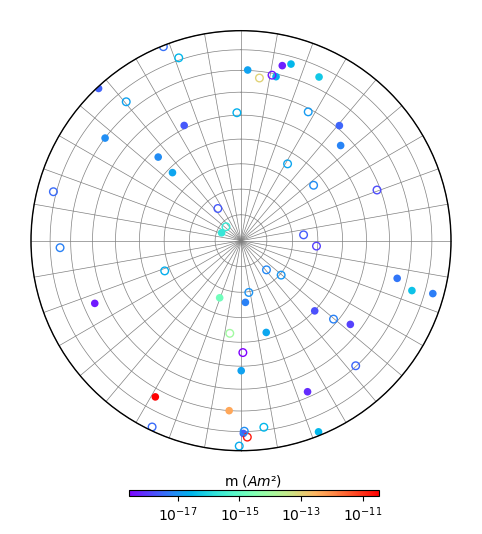

In [14]:
projection = StereographicProjection(dipole_moments_)

import matplotlib.patches
cmap = "rainbow"  # Escolha um colormap
cmap_norm = matplotlib.colors.LogNorm #Normalize
maximum = np.max([len(inclinations)])
kwargs = dict(s=30, cmap=cmap, cmap_norm=cmap_norm)

fig, ax = plt.subplots(figsize=(10, 6))
tmp = projection.plot(ax=ax, add_ticks=False,  **kwargs)

clb = fig.colorbar(
    tmp,
    ax=ax,
    # cax=fig.add_axes([0.5, 0.3, 0.25, 0.01]),
    cax=fig.add_axes([0.4, 0.07, 0.25, 0.01]),
    # format="%.0g",
    orientation="horizontal",
)
clb.set_label(label=r"m ($Am²$)", fontsize=10, labelpad=-37, loc="center")
clb.ax.tick_params(labelsize=10)

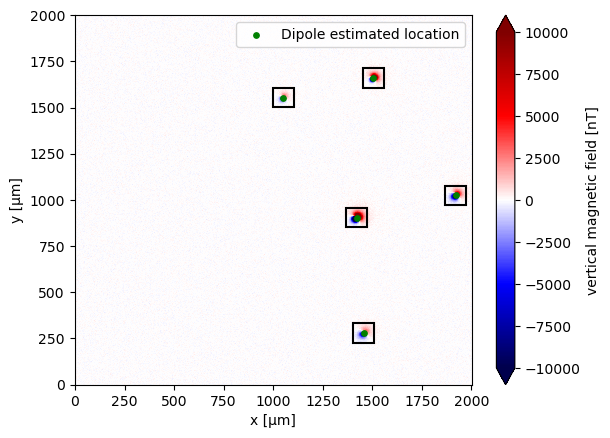

In [32]:
SEED = 42
rng = np.random.default_rng(SEED)

sensor_sample_distance = 5.0
region = [0, 2000, 0, 2000]
spacing = 2.0
true_inclination = 30
true_declination = 40
true_dispersion_angle = 5
size = 5

directions_inclination, directions_declination = mg.random_directions(
    true_inclination,
    true_declination,
    true_dispersion_angle,
    size=size,
    random_state=SEED,
)

dipoles_amplitude = abs(rng.normal(0, 100, size)) * 1.0e-14
dipole_coordinates = (
    rng.integers(30, 1970, size),
    rng.integers(30, 1970, size),
    rng.integers(-20, -1, size),
)

dipole_moments = hm.magnetic_angles_to_vec(
    inclination=directions_inclination,
    declination=directions_declination,
    intensity=dipoles_amplitude,
)

data = mg.dipole_bz_grid(
    region, spacing, sensor_sample_distance, dipole_coordinates, dipole_moments
)
noise_std_dev = 100
data.values += rng.normal(loc=0, scale=noise_std_dev, size=data.shape)


height_difference = 5.0

data_up = (
    hm.upward_continuation(data, height_difference)
    .assign_attrs(data.attrs)
    .assign_coords(x=data.x, y=data.y)
    .assign_coords(z=data.z + height_difference)
    .rename("bz")
)

dx, dy, dz, tga = mg.gradient(data_up)
data_up["dx"], data_up["dy"], data_up["dz"], data_up["tga"] = dx, dy, dz, tga

stretched = skimage.exposure.rescale_intensity(
    tga, in_range=tuple(np.percentile(tga, (1, 99)))
)
data_tga_stretched = xr.DataArray(stretched, coords=data_up.coords)

bounding_boxes = mg.detect_anomalies(
    data_tga_stretched,
    size_range=[50, 150],
    detection_threshold=0.2,
    border_exclusion=2,
    size_multiplier=0.75

)

data_updated, locations_, dipole_moments_, r2_values = mg.iterative_nonlinear_inversion(
    data_up,
    bounding_boxes,
    height_difference=height_difference,
    copy_data=True,
)

fig, ax = plt.subplots()
data.plot.pcolormesh(ax=ax, cmap="seismic", vmin=-10000, vmax=10000)
mg.plot_bounding_boxes(bounding_boxes, ax=ax, color="black", linewidth=1.5)
locations_arr = np.array(locations_)
ax.scatter(
    locations_arr[:, 0],  # x
    locations_arr[:, 1],  # y
    c="green",
    marker=".",
    s=60,
    label="Dipole estimated location"
)
plt.legend()
plt.show()

In [33]:
r2_values

[np.float64(0.9999730958816975),
 np.float64(0.2308337279202256),
 np.float64(0.9994635837733402),
 np.float64(-0.23978014869156716),
 np.float64(-0.27987172539922756)]

In [38]:
dipole_coordinates

(array([1051, 1922, 1457, 1506, 1421]),
 array([1554, 1025,  278, 1659,  903]),
 array([-11, -13, -17,  -3,  -6]))

In [46]:
true_locations= []
for i in range(len(dipole_coordinates[0])):
    # print(i)
    true_locations.append([np.array([dipole_coordinates[0][i], dipole_coordinates[1][i], dipole_coordinates[2][i]])])

true_locations

[[array([1051, 1554,  -11])],
 [array([1922, 1025,  -13])],
 [array([1457,  278,  -17])],
 [array([1506, 1659,   -3])],
 [array([1421,  903,   -6])]]

In [47]:
locations_

[array([1506.00093989, 1658.99927984,   -2.93782875]),
 array([1420.99655888,  903.00145758,    8.80495409]),
 array([1456.78047525,  277.74783346,  -17.31687314]),
 array([1922.29218827, 1024.45004029,   21.9170228 ]),
 array([1051.03705276, 1553.50104637,   30.2232944 ])]

In [ ]:
# import scipy as sp

# tree = sp.spatial.KDTree(np.transpose(true_locations))
# closest = tree.query(np.transpose(locations_))[1]
# z_difference = locations_[2] - np.array(true_locations[2])[closest]

# z_difference

ValueError: data must be of shape (n, m), where there are n points of dimension m